# Modelos de difusión

In [1]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_swiss_roll
import torch
import torch.nn as nn
import torch.optim as optim

## Datos de entrenamiento

In [2]:
def get_batch(batch_size=1000, noise=0.1):
    x, _ = make_swiss_roll(batch_size, noise=noise)
    x = x[:, [0, 2]]
    x = (x - x.mean()) / x.std()
    return torch.tensor(x).float()

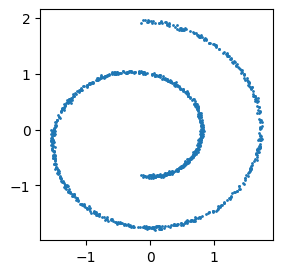

In [3]:
samples = get_batch()
plt.figure(figsize=(3, 3))
plt.scatter(samples[:, 0], samples[:, 1], s=1)
plt.show()

## Implementación de un modelo de difusión incondicional

### Clase `DM`

In [4]:
class DM:

    def __init__(self, model, T=5, initial_alpha=1, final_alpha=0.95):
        self.model = model
        self.T = T
        self.alpha = torch.linspace(initial_alpha, final_alpha, T + 1).unsqueeze(1)
        self.alpha_bar = torch.cumprod(self.alpha, dim=0)

    def mu_q(self, x_0, x_t, t):
        factor1 = self.alpha_bar[t-1].sqrt() * (1 - self.alpha[t]) / (1 - self.alpha_bar[t])
        factor2 = self.alpha[t].sqrt() * (1 - self.alpha_bar[t-1]) / (1 - self.alpha_bar[t])
        mu_q = factor1 * x_0 + factor2 * x_t
        return mu_q

    def sigma2_q(self, t):
        sigma2_q = (1 - self.alpha[t]) * (1 - self.alpha_bar[t-1]) / (1 - self.alpha_bar[t])
        return sigma2_q

    def train(self, optimizer, iters=5000, batch_fn=get_batch):

        for _ in range(iters):
						
			# Monte Carlo:
            x_0 = batch_fn()
            t = torch.randint(1, self.T + 1, size=[len(x_0)])
            x_t = self.alpha_bar[t].sqrt() * x_0 + (1-self.alpha_bar[t]).sqrt() * torch.randn_like(x_0)

            # Error cuadrático esperado:
            loss = (self.mu_q(x_0, x_t, t) - self.model(x_t, t)).norm(dim=-1) ** 2
            loss = loss.mean()

            # Optimización:
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
    
    def ancestral_sampling(self, n_samples, data_dim=2):

        x_t = torch.randn(n_samples, data_dim)
        
        for t in reversed(range(1, self.T + 1)):
            t_batch = t * torch.ones(n_samples)
            mu_theta = self.model(x_t, t_batch)
            sigma_theta = self.sigma2_q(t).sqrt()
            x_t = mu_theta + sigma_theta * torch.randn_like(x_t)

        return x_t.detach()

### Red neuronal

In [5]:
class DiffusionNetwork(nn.Module):

    def __init__(self, data_dim=2, hidden_dim=128):
        super().__init__()

        self.model = nn.Sequential(
            nn.Linear(data_dim + 1, hidden_dim), nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim), nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim), nn.ReLU(),
            nn.Linear(hidden_dim, data_dim)
        )

    def forward(self, x_t, t):
        input = torch.cat([x_t, t.unsqueeze(1)], dim=1)
        mu_theta = self.model(input)
        return mu_theta

### Entrenamiento

In [6]:
model = DiffusionNetwork()
dm = DM(model)

optimizer = optim.AdamW(model.parameters())
dm.train(optimizer, iters=5000)

### Generación

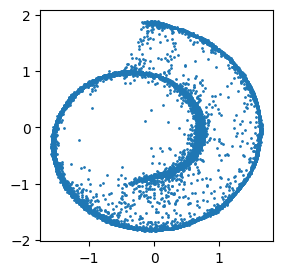

In [7]:
samples = dm.ancestral_sampling(n_samples=10000)
plt.figure(figsize=(3, 3))
plt.scatter(samples[:, 0], samples[:, 1], s=1)
plt.show()

## Classifier guidance

### Sampling modificado

In [8]:
class GuidanceDM(DM):

    def ancestral_sampling(self, n_samples, data_dim=2, y=None, discriminator_grad_fn=None, scale=1):

        x_t = torch.randn(n_samples, data_dim)
        
        for t in reversed(range(1, self.T + 1)):
            t_batch = t * torch.ones(n_samples).long()
            mu_theta_incond = self.model(x_t, t_batch)
            sigma_theta = self.sigma2_q(t).sqrt()

            if y is not None:
                discriminator_grad = discriminator_grad_fn(x_t, y)
                factor = (1 - self.alpha[t]) / self.alpha[t].sqrt()
                mu_theta_cond = mu_theta_incond + scale * (factor * discriminator_grad)
            else:
                mu_theta_cond = mu_theta_incond

            x_t = mu_theta_cond + sigma_theta * torch.randn_like(x_t)

        return x_t.detach()

### Clasificador

In [9]:
def position_discriminator_grad(x_t, y):
    y = torch.tensor(y).unsqueeze(0)
    discriminator_grad = 1/2 * (y - x_t)
    return discriminator_grad

### Generación condicional

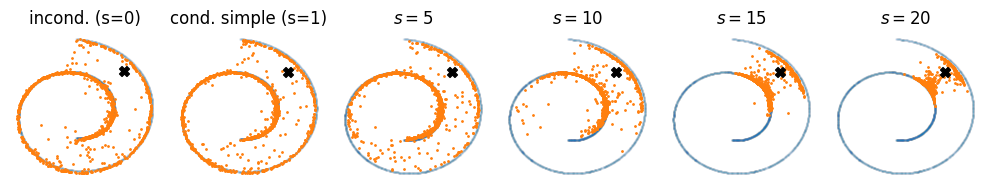

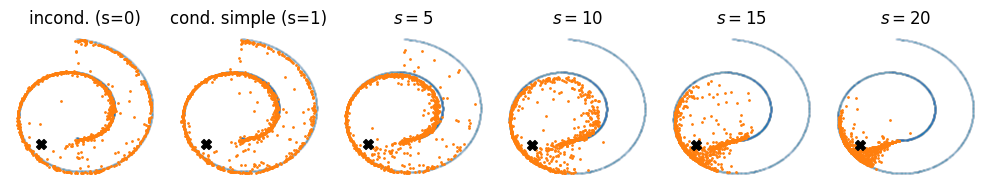

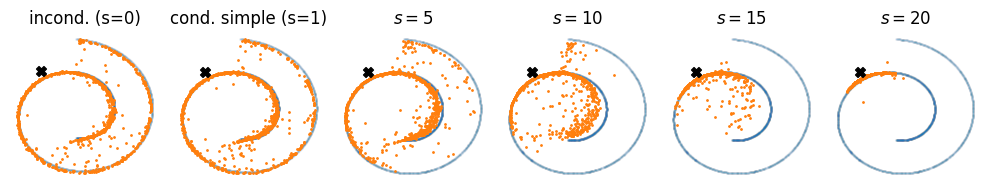

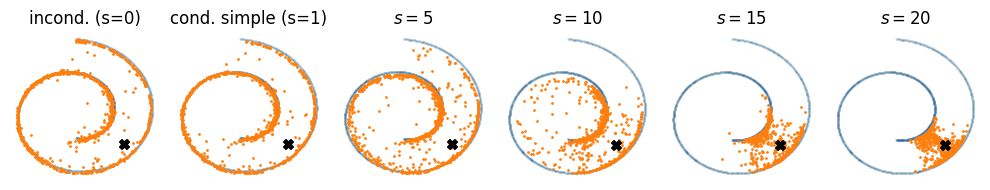

In [10]:
conditional_dm = GuidanceDM(model)

true_data = get_batch(10000, noise=0)
scales = [0, 1, 5, 10, 15, 20]

for center in ([1, 1], [-1, -1], [-1, 1], [1, -1]):
    
    plt.figure(figsize=(10, 2))

    for idx, s in enumerate(scales):

        samples = conditional_dm.ancestral_sampling(n_samples=1000, data_dim=2, y=center, discriminator_grad_fn=position_discriminator_grad, scale=s)

        plt.subplot(1, len(scales), idx+1)
        plt.scatter(true_data[:, 0], true_data[:, 1], s=1, alpha=0.01)
        plt.scatter(samples[:, 0], samples[:, 1], s=1)
        plt.scatter(*center, s=50, c='k', marker='X')
        title = 'incond. (s=0)' if s == 0 else 'cond. simple (s=1)' if s==1 else f'$s={s}$'
        plt.title(title)
        plt.axis('off')
        
    plt.tight_layout()
    plt.show()